In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from yellowbrick.cluster import KElbowVisualizer

X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

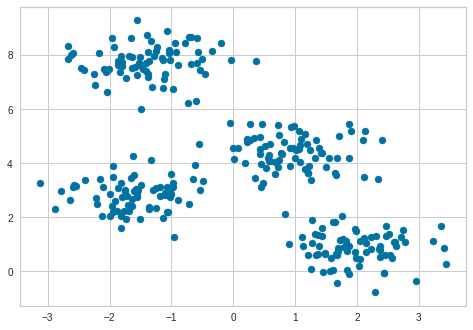

In [2]:
model = KMeans()
plt.scatter(X[:,0], X[:,1], s=50)

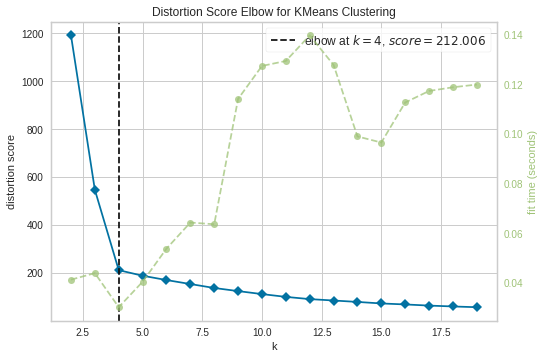

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [3]:
visualizer = KElbowVisualizer(model, k = (2, 20))
visualizer.fit(X)
visualizer.show()

In [4]:
from sklearn.metrics import confusion_matrix
clusters = model.fit_predict(X)
model.cluster_centers_.shape

(19, 2)

In [5]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(model.cluster_centers_.shape[0]):
    mask = (clusters == i)
    labels[mask] = mode(y_true[mask])[0]
    
print(labels.shape)
print(labels)




(300,)
[1 3 0 3 1 1 2 0 3 3 2 3 0 3 1 0 0 1 2 2 1 1 0 2 2 0 1 0 2 0 3 3 0 3 3 3 3
 3 2 1 0 2 0 0 2 2 3 2 3 1 2 1 3 1 1 2 3 2 3 1 3 0 3 2 2 2 3 1 3 2 0 2 3 2
 2 3 2 0 1 3 1 0 1 1 3 0 1 0 3 3 0 1 3 2 2 0 1 1 0 2 3 1 3 1 0 1 1 0 3 0 2
 2 1 3 1 0 3 1 1 0 2 1 2 1 1 1 1 2 1 2 3 2 2 1 3 2 2 3 0 3 3 2 0 2 0 2 3 0
 3 3 3 0 3 0 1 2 3 2 1 0 3 0 0 1 0 2 2 0 1 0 0 3 1 0 2 3 1 1 0 2 1 0 2 2 0
 0 0 0 1 3 0 2 0 0 2 2 2 0 2 3 0 2 1 2 0 3 2 3 0 3 0 2 0 0 3 2 2 1 1 0 3 1
 1 2 1 2 0 3 3 0 0 3 0 1 2 0 1 2 3 2 1 0 1 3 3 3 3 2 2 3 0 2 1 0 2 2 2 1 1
 3 0 0 2 1 3 2 0 3 0 1 1 2 2 0 1 1 1 0 3 3 1 1 0 1 1 1 3 2 3 0 1 1 3 3 3 1
 1 0 3 2]


In [6]:
from sklearn.metrics import accuracy_score
accuracy_score(y_true, labels)

1.0

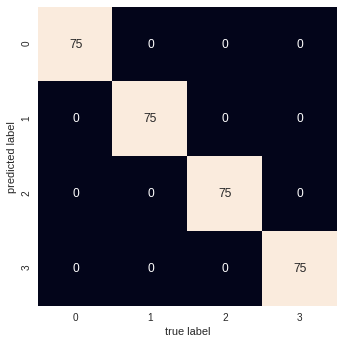

In [7]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_true, labels)
sns.heatmap(mat.T, square = True, annot = True, fmt='d', cbar=False,
           xticklabels =['0','1','2', '3'], yticklabels =['0', '1', '2','3'] )
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.savefig('HW2_Confusion_Matrix.png')
